In [ ]:
#LIBRARIES
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (2).zip


In [ ]:
#DATASET UPLOAD
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted files:")
print(os.listdir("dataset"))

Extracted files:
['Fake_Real_Data.csv']


In [ ]:
#CSV LOAD
df = pd.read_csv("dataset/Fake_Real_Data.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (9900, 2)

Columns:
['Text', 'label']


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [ ]:
#DATASET CHECK
print("Missing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

Missing values:
Text     0
label    0
dtype: int64

Label distribution:
label
Fake    5000
Real    4900
Name: count, dtype: int64


In [ ]:
#CLEAN DATA
df = df[["Text", "label"]].copy()

df["Text"] = df["Text"].fillna("")
df["label"] = df["label"].fillna("")

df["Text"] = df["Text"].astype(str)
df["label"] = df["label"].astype(str).str.strip().str.lower()

df = df[df["Text"].str.strip() != ""]

print(df.shape)
print(df["label"].value_counts())


(9900, 2)
label
fake    5000
real    4900
Name: count, dtype: int64


In [ ]:
#CONVERT FAKE/REAL INT0 0/1
df["label"] = df["label"].map({
    "fake": 0,
    "real": 1
})

df = df.dropna(subset=["label"])

df["label"] = df["label"].astype(int)

print(df["label"].value_counts())

label
0    5000
1    4900
Name: count, dtype: int64


In [ ]:
#TEXT CLEANING
def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["Text"].apply(clean_text)

display(df[["Text", "clean_text", "label"]].head())

,Text,clean_text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,top trump surrogate brutally stabs him in the ...,0
1,U.S. conservative leader optimistic of common ...,us conservative leader optimistic of common gr...,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",trump proposes us tax overhaul stirs concerns ...,1
3,Court Forces Ohio To Allow Millions Of Illega...,court forces ohio to allow millions of illegal...,0
4,Democrats say Trump agrees to work on immigrat...,democrats say trump agrees to work on immigrat...,1


In [ ]:
#X AND Y
X = df["clean_text"]
y = df["label"]

print("Total articles:", len(X))
print("Fake:", sum(y == 0))
print("Real:", sum(y == 1))

Total articles: 9900
Fake: 5000
Real: 4900


In [ ]:
#TRAIN/TEST/SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7920
Testing samples: 1980


In [ ]:
#TOKENIZATION
max_words = 10000
max_len = 200

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)

X_train shape: (7920, 200)
X_test shape: (1980, 200)


In [ ]:
#LSTM MODEL
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    LSTM(128),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#TRAIN
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 60s 610ms/step - accuracy: 0.8933 - loss: 0.2662 - val_accuracy: 0.8371 - val_loss: 0.3267
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 68s 473ms/step - accuracy: 0.8696 - loss: 0.2986 - val_accuracy: 0.8832 - val_loss: 0.2648
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 44s 447ms/step - accuracy: 0.9258 - loss: 0.1893 - val_accuracy: 0.8813 - val_loss: 0.2397
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 463ms/step - accuracy: 0.9765 - loss: 0.0709 - val_accuracy: 0.9388 - val_loss: 0.1427
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 461ms/step - accuracy: 0.9890 - loss: 0.0409 - val_accuracy: 0.9545 - val_loss: 0.1805
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 468ms/step - accuracy: 0.8911 - loss: 0.3309 - val_accuracy: 0.8434 - val_loss: 0.3513
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 466ms/step - accuracy: 0.8701 - loss: 0.3056 - val_accuracy: 0.8561 - val_loss: 0.3350


In [ ]:
#ACCURACY
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", round(accuracy * 100, 2), "%")

Test Loss: 0.10008113086223602
Test Accuracy: 97.12 %


In [ ]:
#PREDICTION/CLASSIFICATION REPORT
y_pred_probability = model.predict(
    X_test_pad,
    verbose=0
)

y_pred = (y_pred_probability >= 0.5).astype(int).flatten()

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

Accuracy: 97.12 %

Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.96      0.97      1000
        Real       0.96      0.98      0.97       980

    accuracy                           0.97      1980
   macro avg       0.97      0.97      0.97      1980
weighted avg       0.97      0.97      0.97      1980



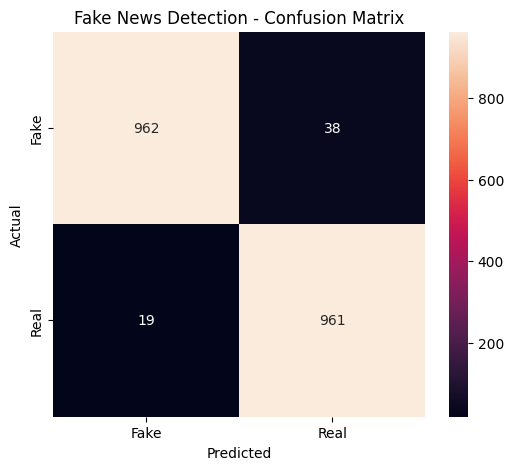

In [ ]:
#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fake News Detection - Confusion Matrix")

plt.show()

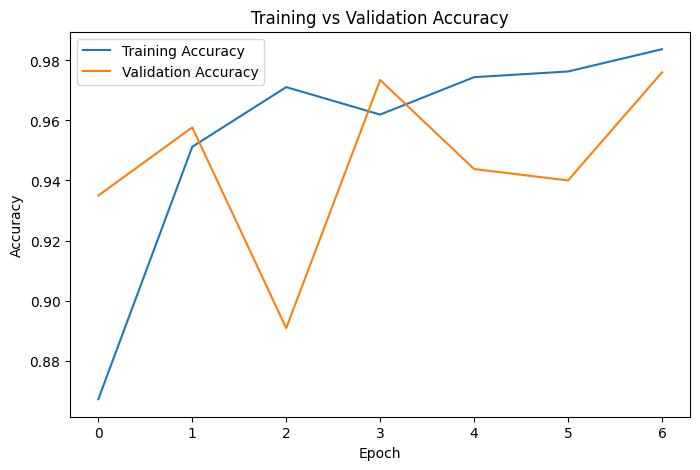

In [ ]:
#ACCURACY GRAPH
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

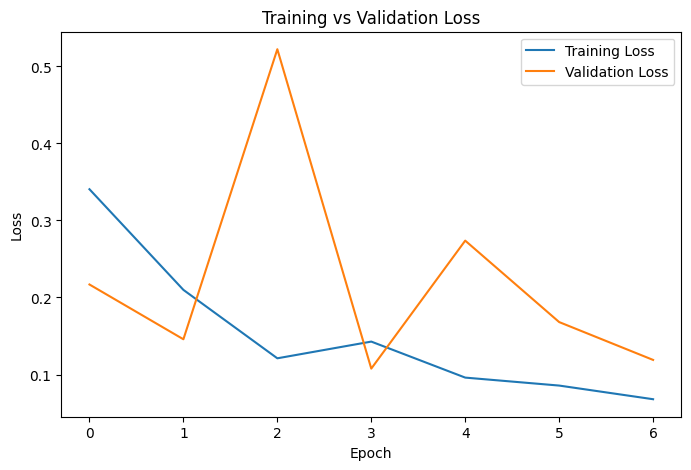

In [ ]:
#LOSS GRAPH
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [ ]:
#CHECKING
def predict_news(news_text):

    cleaned_text = clean_text(news_text)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    probability = model.predict(
        padded,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        prediction = "REAL NEWS"
        confidence = probability * 100
    else:
        prediction = "FAKE NEWS"
        confidence = (1 - probability) * 100

    print("Prediction:", prediction)
    print("Confidence:", round(confidence, 2), "%")

In [ ]:
#TEST
news = """
The government announced a new policy that will provide
additional digital learning facilities to students.
"""

predict_news(news)

Prediction: REAL NEWS
Confidence: 99.99 %


In [ ]:
print(df[df["label"] == 0]["Text"].iloc[0])

 Top Trump Surrogate BRUTALLY Stabs Him In The Back: ‘He’s Pathetic’ (VIDEO) It s looking as though Republican presidential candidate Donald Trump is losing support even from within his own ranks. You know things are getting bad when even your top surrogates start turning against you, which is exactly what just happened on Fox News when Newt Gingrich called Trump  pathetic. Gingrich knows that Trump needs to keep his focus on Hillary Clinton if he even remotely wants to have a chance at defeating her. However, Trump has hurt feelings because many Republicans don t support his sexual assault against women have turned against him, including House Speaker Paul Ryan (R-WI). So, that has made Trump lash out as his own party.Gingrich said on Fox News: Look, first of all, let me just say about Trump, who I admire and I ve tried to help as much as I can. There s a big Trump and a little Trump. The little Trump is frankly pathetic. I mean, he s mad over not getting a phone call? Trump s referri